<a href="https://colab.research.google.com/github/priyankan15/Assignment-4/blob/main/Team17EndTerm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================
# PART 1
# Data Acquisition, Wrangling, EDA, Spark SQL
# ============================

# --- 0) Environment Setup  ---

!pip -q install pyspark==3.5.2 pyarrow==16.1.0

import os, sys, time
import pyspark
from pyspark.sql import SparkSession, functions as F, types as T, Window

print("PySpark version:", pyspark.__version__)

# Build Spark session
spark = (
    SparkSession.builder
    .appName("MS_Assignment_Part1")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate()
)

spark


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 11.6 MB/s eta 0:00:00
PySpark version: 3.5.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ---------- File paths ----------
REVIEW_PATH = "/content/drive/MyDrive/Colab Notebooks/Python Course/review.csv"
META_PATH = "/content/drive/MyDrive/Colab Notebooks/Python Course/meta-review-business.csv"

In [5]:
# ---------- Read CSVs with Spark ----------
read_opts = dict(header=True, inferSchema=True, multiLine=True, escape='"', quote='"')
df_review = spark.read.options(**read_opts).csv(REVIEW_PATH)
df_meta   = spark.read.options(**read_opts).csv(META_PATH)

In [6]:
# ---------- Helper: locate columns ignoring case ----------
def col_case_insensitive(df, name):
    m = {c.lower(): c for c in df.columns}
    if name.lower() not in m:
        raise ValueError(f"Column '{name}' not found. Available columns: {df.columns}")
    return m[name.lower()]

text_col = col_case_insensitive(df_review, "text")
time_col = col_case_insensitive(df_review, "time")


In [7]:
# =======================================================
# 1.1.1 Replace None/null/'none'/'null'/'' with 'no review'
# =======================================================
df_review_clean = df_review.withColumn(
    text_col,
    F.when(
        F.col(text_col).isNull() |
        (F.trim(F.col(text_col)) == "") |
        (F.lower(F.col(text_col)) == "none") |
        (F.lower(F.col(text_col)) == "null"),
        F.lit("no review")
    ).otherwise(F.col(text_col))
)


In [8]:
# =======================================================
# 1.1.2 Parsing `time` and creating `newtime` in yyyy-MM-dd
# =======================================================
from pyspark.sql import functions as F, types as T

# We will build two branches:
#  A) Numeric/epoch path (BIGINT): supports seconds and milliseconds
#  B) String path: try multiple date-time patterns safely by casting to string

# ------------- A) NUMERIC / EPOCH -------------
# If time is BIGINT -> treat as epoch. If >= 10^12 it's likely milliseconds.
time_as_long = F.col(time_col).cast("long")

epoch_secs = F.when(
    time_as_long.isNotNull(),
    F.when(time_as_long >= F.lit(10**12), (time_as_long / F.lit(1000)).cast("long"))  # ms -> s
     .otherwise(time_as_long)
)

epoch_ts = F.when(
    time_as_long.isNotNull(),
    F.from_unixtime(epoch_secs).cast("timestamp")
)


In [9]:
# ------------- B) STRING / PATTERN PARSE -------------
# Cast to string for unix_timestamp(pattern) to avoid type errors
time_as_str = F.col(time_col).cast("string")

patterns = [
    "yyyy-MM-dd HH:mm:ss",
    "yyyy/MM/dd HH:mm:ss",
    "yyyy-MM-dd",
    "yyyy/MM/dd",
    "MM/dd/yyyy",
    "dd/MM/yyyy",
    "yyyy-MM-dd'T'HH:mm:ss'Z'",
    "yyyy-MM-dd'T'HH:mm:ssXXX",
    "yyyy-MM-dd'T'HH:mm:ss.SSS'Z'",
]

parsed_candidates = [epoch_ts]  # epoch first
for p in patterns:
    parsed_candidates.append(
        F.from_unixtime(F.unix_timestamp(time_as_str, p)).cast("timestamp")
    )

# First non-null parse wins
parsed_ts = F.coalesce(*parsed_candidates)

# Final formatted date as required
df_review_clean = df_review_clean.withColumn("newtime", F.date_format(parsed_ts, "yyyy-MM-dd"))

# Show first 5 rows
df_review_clean.select(text_col, time_col, "newtime").show(5, truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+----------+
|text                                                                                                                                                                                                                               

In [10]:
# ---------------------------------
# 1.2.1 Number of reviews per gmap_id (float)
# ---------------------------------
# Group by gmap_id and count reviews
df_gmap_reviews = (
    df_review_clean
    .groupBy("gmap_id")
    .agg(F.count("*").cast("float").alias("review_count"))
    .orderBy(F.desc("review_count"))
)

print("Top 5 gmap_id by review count (PySpark DataFrame):")
df_gmap_reviews.show(5, truncate=False)

Top 5 gmap_id by review count (PySpark DataFrame):
+-------------------------------------+------------+
|gmap_id                              |review_count|
+-------------------------------------+------------+
|0x56c897b9ce6000df:0xd707e127588a8c6c|2833.0      |
|0x56c899d058920487:0x12882cc9133f2f54|2594.0      |
|0x56c897c63697ee39:0x419904ababbc740b|2258.0      |
|0x56c8965ee2fb87a1:0x559736347bd48842|2237.0      |
|0x56c89629bde7481f:0x7e8a9413ab25d5d |2219.0      |
+-------------------------------------+------------+
only showing top 5 rows



In [11]:
# ---------------------------------
# 1.2.2 Convert to Pandas and create review_time (hour-level)
# ---------------------------------
# Convert PySpark to Pandas
df = df_review_clean.select("gmap_id", "newtime", time_col).limit(10000).toPandas()

# Parse the numeric/string `time` to datetime (in pandas)
# Spark gave us ms epoch numbers in Q1.1. Convert them properly here.
df["time"] = pd.to_numeric(df[time_col], errors="coerce")

# Detect ms vs sec: values > 1e12 are ms
df["time_dt"] = pd.to_datetime(
    df["time"].apply(lambda x: x/1000 if x and x > 1e12 else x),
    unit="s", errors="coerce"
)

# Create review_time = hour of day (0-23)
df["review_time"] = df["time_dt"].dt.hour

print("\nPandas DataFrame with review_time column (top 5 rows):")
print(df.head())


Pandas DataFrame with review_time column (top 5 rows):
                                 gmap_id     newtime           time  \
0  0x56b646ed2220b77f:0xd8975e316de80952  2019-08-20  1566331951619   
1  0x56b646ed2220b77f:0xd8975e316de80952  2017-09-09  1504917982385   
2  0x56b646ed2220b77f:0xd8975e316de80952  2016-09-25  1474765901185   
3  0x56b646ed2220b77f:0xd8975e316de80952  2016-09-02  1472858535682   
4  0x56b646ed2220b77f:0xd8975e316de80952  2018-06-22  1529649811341   

                        time_dt  review_time  
0 2019-08-20 20:12:31.618999958           20  
1 2017-09-09 00:46:22.384999990            0  
2 2016-09-25 01:11:41.184999943            1  
3 2016-09-02 23:22:15.681999922           23  
4 2018-06-22 06:43:31.341000080            6  


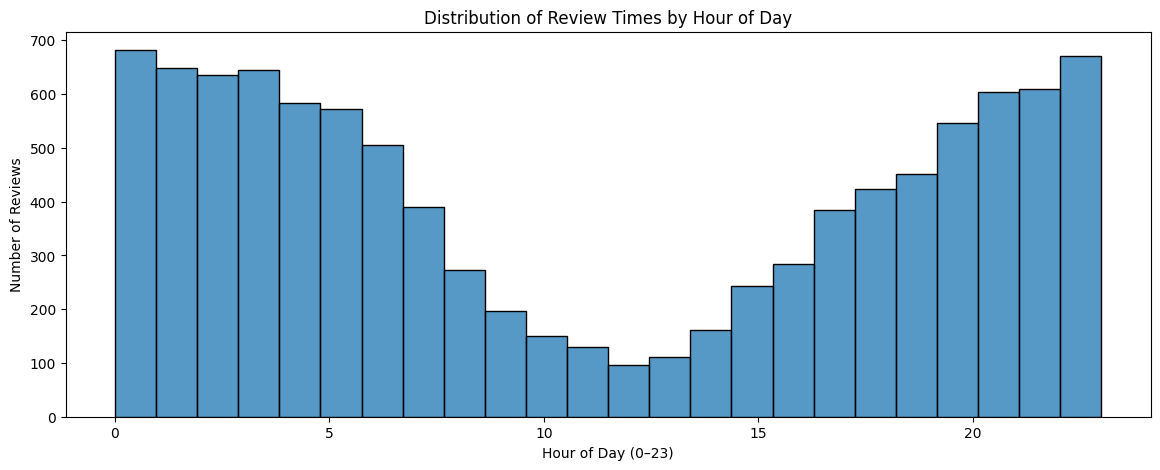

/tmp/ipython-input-447687281.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="review_time", y="gmap_id", data=avg_by_hour, palette="viridis")


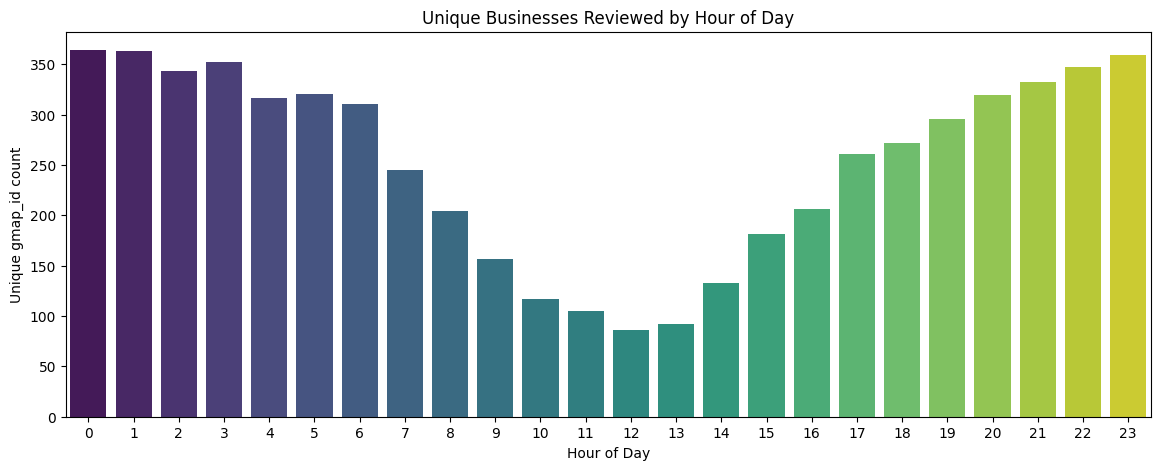

In [12]:
# ---------------------------------
# 1.2.3 Visualizations
# ---------------------------------
plt.figure(figsize=(14, 5))

# Plot 1: Distribution of review times (what hours are reviews posted?)
sns.histplot(df["review_time"].dropna(), bins=24, kde=False)
plt.title("Distribution of Review Times by Hour of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Reviews")
plt.show()

# Plot 2: Average reviews per gmap_id vs hour
plt.figure(figsize=(14, 5))
avg_by_hour = df.groupby("review_time")["gmap_id"].nunique().reset_index()
sns.barplot(x="review_time", y="gmap_id", data=avg_by_hour, palette="viridis")
plt.title("Unique Businesses Reviewed by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Unique gmap_id count")
plt.show()


In [13]:
# ---------------------------------
# Join Review & Meta Data
# ---------------------------------

# Rename meta-business columns to avoid ambiguity
df_meta_renamed = (
    df_meta
    .withColumnRenamed("name", "business_name")
    .withColumnRenamed("category", "business_category")
)

# Join on gmap_id
df_joined = df_review_clean.join(df_meta_renamed, on="gmap_id", how="inner")

# Convert Spark DataFrame -> Pandas for time-based analysis
df = df_joined.select(
    "gmap_id", "time", "rating", "business_name", "business_category"
).limit(200000).toPandas()

# Parse time into datetime (already ms epoch in your dataset)
df["time"] = pd.to_numeric(df["time"], errors="coerce")
df["time_dt"] = pd.to_datetime(
    df["time"].apply(lambda x: x/1000 if x and x > 1e12 else x),
    unit="s", errors="coerce"
)

# Extract weekday (0=Monday, 6=Sunday)
df["weekday"] = df["time_dt"].dt.dayofweek
weekday_map = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}
df["weekday_name"] = df["weekday"].map(weekday_map)

# Extract review hour
df["review_hour"] = df["time_dt"].dt.hour


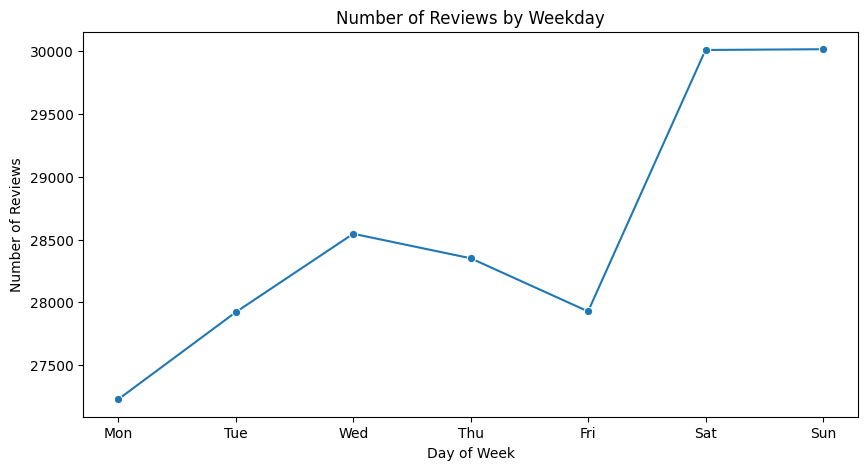

The weekday with most reviews is: Sun


In [14]:
# ---------------------------------
# 1.3.1 Which weekday generates most reviews?
# ---------------------------------

# Count reviews per weekday
reviews_per_day = df.groupby("weekday_name")["gmap_id"].count().reset_index()

# Keep correct weekday order
reviews_per_day["weekday_order"] = reviews_per_day["weekday_name"].map(
    {"Mon":0, "Tue":1, "Wed":2, "Thu":3, "Fri":4, "Sat":5, "Sun":6}
)
reviews_per_day = reviews_per_day.sort_values("weekday_order")

# Line chart of reviews by weekday
plt.figure(figsize=(10,5))
sns.lineplot(data=reviews_per_day, x="weekday_name", y="gmap_id", marker="o")
plt.title("Number of Reviews by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Number of Reviews")
plt.show()

# Find weekday with most reviews
most_active_day = reviews_per_day.loc[reviews_per_day["gmap_id"].idxmax(), "weekday_name"]
print("The weekday with most reviews is:", most_active_day)


In [15]:
# ---------------------------------
# 1.3.2 Top businesses with highest average ratings on that day
# ---------------------------------

# Filter only reviews from the most active weekday
df_day = df[df["weekday_name"] == most_active_day]

# Group by business and category, compute average rating
top_businesses = (
    df_day.groupby(["business_name", "business_category"])["rating"]
    .mean()
    .reset_index()
    .sort_values("rating", ascending=False)
    .head(10)
)

import ast
tb = top_businesses.copy()

# Ensure category is a readable comma-separated string
def norm_cat(val):
    if isinstance(val, str):
        try:
            lst = ast.literal_eval(val)
            if isinstance(lst, (list, tuple)):
                return ", ".join(lst)
        except Exception:
            pass
    if isinstance(val, (list, tuple)):
        return ", ".join(val)
    return str(val)

tb["business_category"] = tb["business_category"].apply(norm_cat)
tb["Avg. Rating"] = tb["rating"].round(2)
tb = tb.drop(columns=["rating"])

tb.insert(0, "Rank", range(1, len(tb) + 1))
tb.rename(columns={"business_name": "Business Name", "business_category": "Category"}, inplace=True)

print(tb.to_string(index=False))

 Rank                                               Business Name                                                                                                         Category  Avg. Rating
    1                                    13 Ravens Coffee & Books                                                                                    Coffee shop, Book store, Cafe          5.0
    2 🚚Eagle Towing Anchorage Girdwood Eagle River Palmer Wasilla                                                                           Towing service, Transportation service          5.0
    3                                                203 Kombucha                                                                                                        Tea house          5.0
    4                                 Zack's Famous Frozen Yogurt                                                      Dessert shop, Bubble tea store, Coffee shop, Ice cream shop          5.0
    5                                   

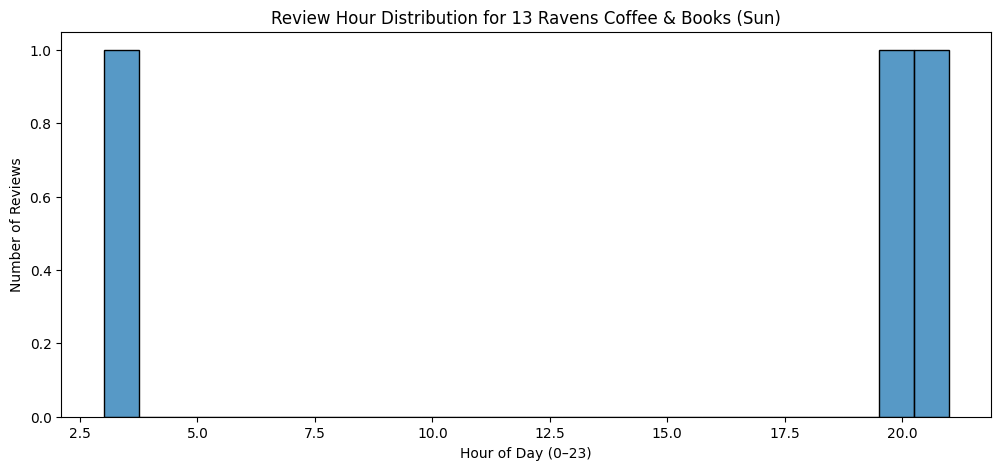

 Rank                                               Business Name                                                    Category  Avg. Rating  Peak Review Hour
    1                                    13 Ravens Coffee & Books                               Coffee shop, Book store, Cafe          5.0                 3
    2 🚚Eagle Towing Anchorage Girdwood Eagle River Palmer Wasilla                      Towing service, Transportation service          5.0                 0
    3                                                203 Kombucha                                                   Tea house          5.0                 1
    4                                 Zack's Famous Frozen Yogurt Dessert shop, Bubble tea store, Coffee shop, Ice cream shop          5.0                 8
    5                                            A Desert Passage                                    Jewelry store, Rock shop          5.0                 1


In [16]:
# ---------------------------------
# 1.3.3 Further Exploration
# ---------------------------------

# Pick the top-rated business
best_business = top_businesses.iloc[0]["business_name"]
df_best = df_day[df_day["business_name"] == best_business]

# Histogram of review hours for top business
plt.figure(figsize=(12,5))
sns.histplot(df_best["review_hour"], bins=24, kde=False)
plt.title(f"Review Hour Distribution for {best_business} ({most_active_day})")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Reviews")
plt.show()

# Table: avg rating + peak hour for top 5 businesses
peak_info = (
    df_day.groupby(["business_name", "business_category"])
    .agg(
        avg_rating=("rating", "mean"),
        peak_hour=("review_hour", lambda x: x.value_counts().idxmax())
    )
    .reset_index()
    .sort_values("avg_rating", ascending=False)
    .head(5)
)

# Copy the peak_info DataFrame
df_out = peak_info.copy().reset_index(drop=True)

# Normalize category column into readable string
def norm_cat(val):
    if isinstance(val, str):
        try:
            lst = ast.literal_eval(val)
            if isinstance(lst, (list, tuple)):
                return ", ".join(lst)
        except Exception:
            pass
    if isinstance(val, (list, tuple)):
        return ", ".join(val)
    return str(val)

df_out["business_category"] = df_out["business_category"].apply(norm_cat)

# Round average rating to 2 decimals
df_out["avg_rating"] = df_out["avg_rating"].round(2)

# Add Rank column
df_out.insert(0, "Rank", range(1, len(df_out) + 1))

# Rename columns for clean table
df_out.rename(columns={
    "business_name": "Business Name",
    "business_category": "Category",
    "avg_rating": "Avg. Rating",
    "peak_hour": "Peak Review Hour"
}, inplace=True)

# Print structured table
print(df_out.to_string(index=False))

In [17]:
from collections import Counter
from wordcloud import WordCloud
import re
# ==============================================================
# PART 1 — Q1.4
# Word frequency analysis + Word clouds by year
# ==============================================================
# ---------------------------------
# Prepare review text
# ---------------------------------
# Convert review Spark DataFrame to Pandas (only text + date for analysis)
df_text = df_review_clean.select("text", "newtime").toPandas()

# Ensure datetime
df_text["newtime"] = pd.to_datetime(df_text["newtime"], errors="coerce")
df_text["year"] = df_text["newtime"].dt.year

# Drop rows with no text
df_text = df_text.dropna(subset=["text"])

# ---------------------------------
# Clean and tokenize text
# ---------------------------------
def clean_text(text):
    text = str(text).lower()                           # lowercase
    text = re.sub(r"http\S+", "", text)                # remove links
    text = re.sub(r"[^a-z\s]", "", text)               # keep only letters
    text = re.sub(r"\s+", " ", text).strip()           # remove extra spaces
    return text

df_text["clean_text"] = df_text["text"].apply(clean_text)

# Tokenize
df_text["tokens"] = df_text["clean_text"].apply(lambda x: x.split())


In [18]:
# ---------------------------------
# Stopwords removal
# ---------------------------------
from nltk.corpus import stopwords
import nltk
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
df_text["tokens"] = df_text["tokens"].apply(lambda tokens: [w for w in tokens if w not in stop_words and len(w) > 2])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Top 30 Most Common Words in All Reviews:

     Word  Frequency
   review     224464
    great      82931
     good      64356
     food      63265
    place      47991
  service      45771
    staff      28824
     nice      26480
 friendly      26414
   always      23685
     best      21971
      get      20847
     love      19933
     time      18923
     like      16929
      one      15785
   really      12631
    clean      12603
   people      12564
  amazing      12524
   prices      12305
    store      12073
  awesome      12054
     back      11931
     well      11901
    would      11291
  helpful      10654
   little      10465
excellent      10322
     dont       9695


/tmp/ipython-input-1096115833.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top30_df, x="Frequency", y="Word", palette="viridis")


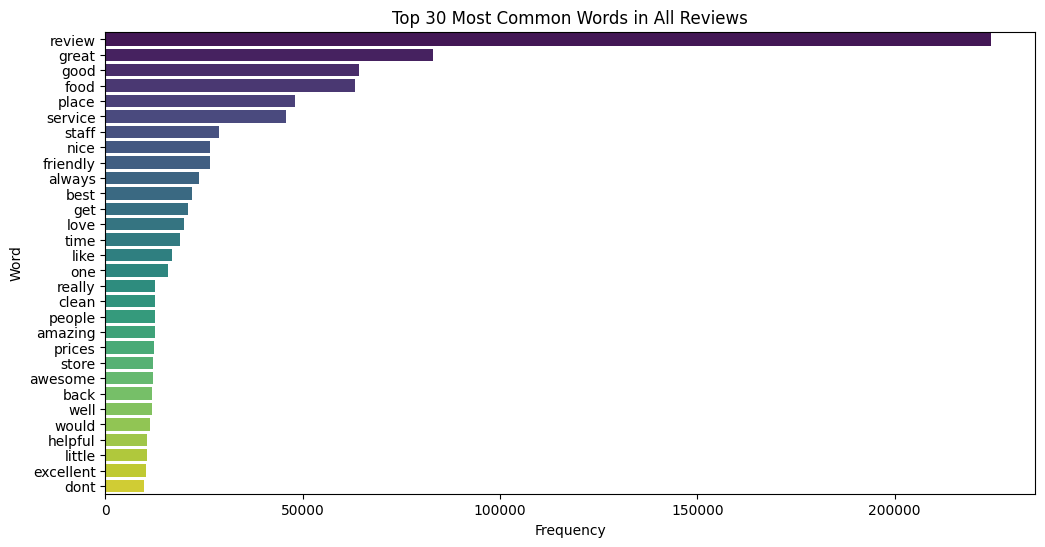

In [19]:
# ---------------------------------
# Top 30 most common words (overall)
# ---------------------------------
all_words = [word for tokens in df_text["tokens"] for word in tokens]
word_counts = Counter(all_words)
top30 = word_counts.most_common(30)

# Display top 30 as a table
top30_df = pd.DataFrame(top30, columns=["Word", "Frequency"])
print("Top 30 Most Common Words in All Reviews:\n")
print(top30_df.to_string(index=False))

# Plot bar chart
plt.figure(figsize=(12,6))
sns.barplot(data=top30_df, x="Frequency", y="Word", palette="viridis")
plt.title("Top 30 Most Common Words in All Reviews")
plt.show()

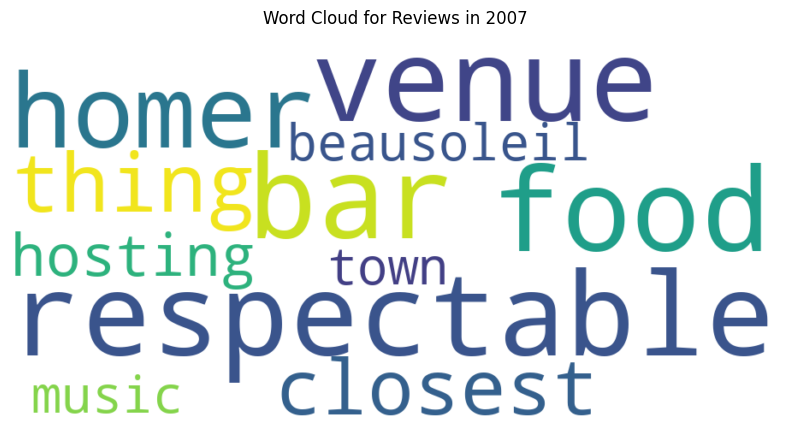

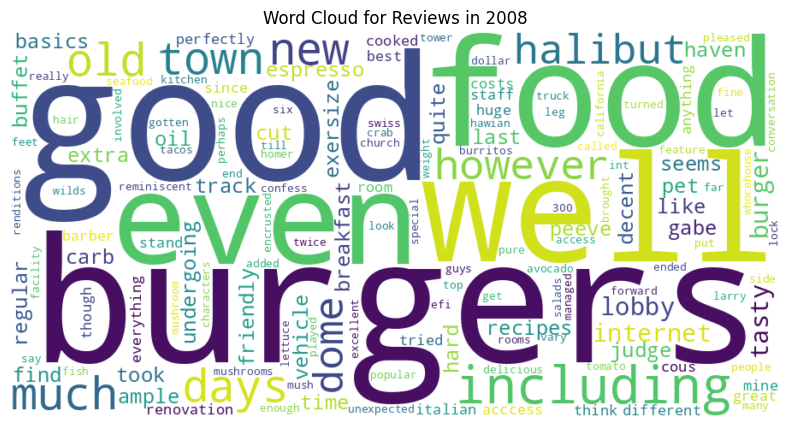

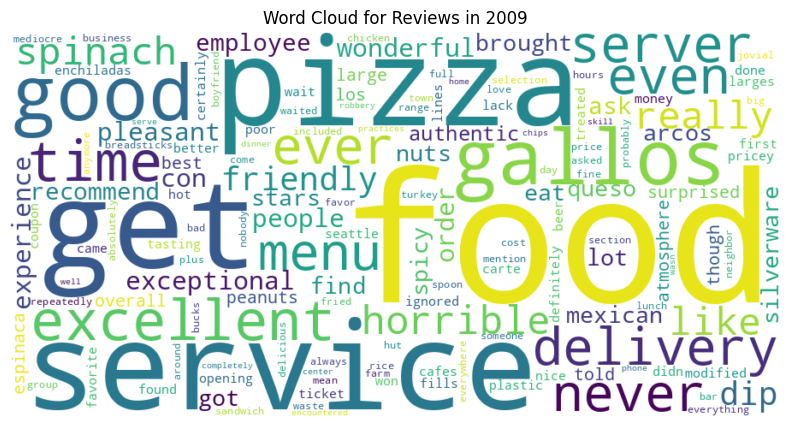

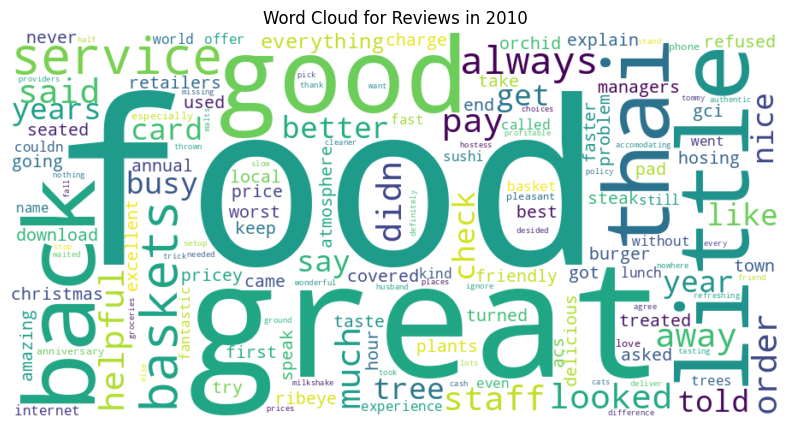

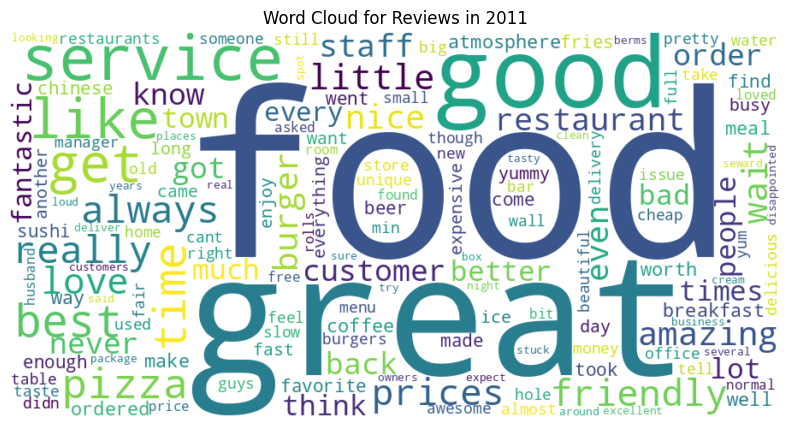

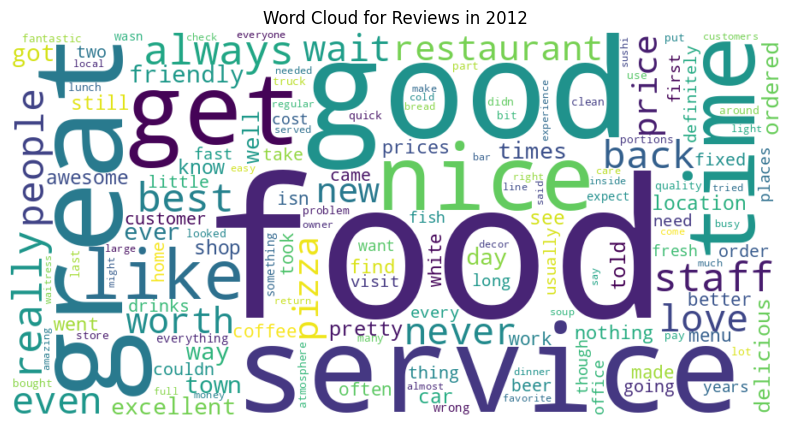

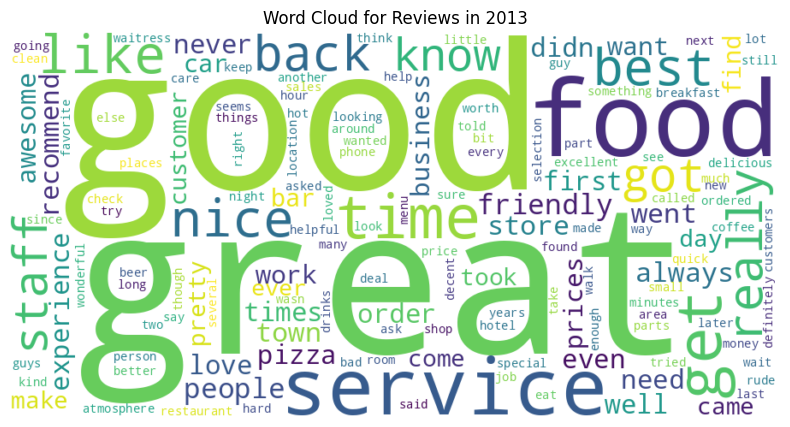

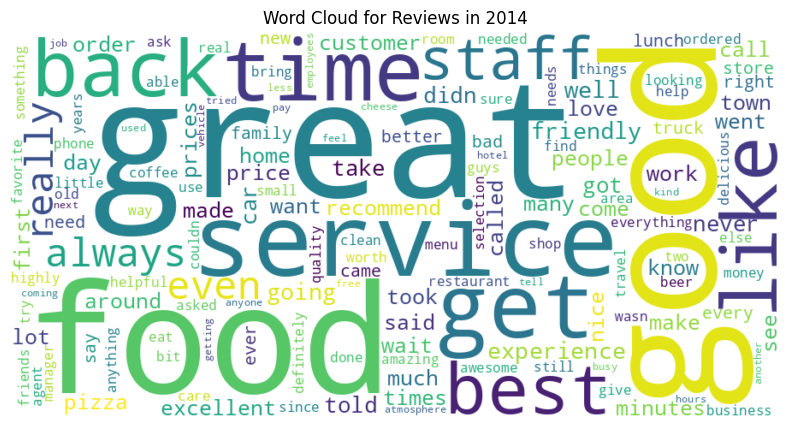

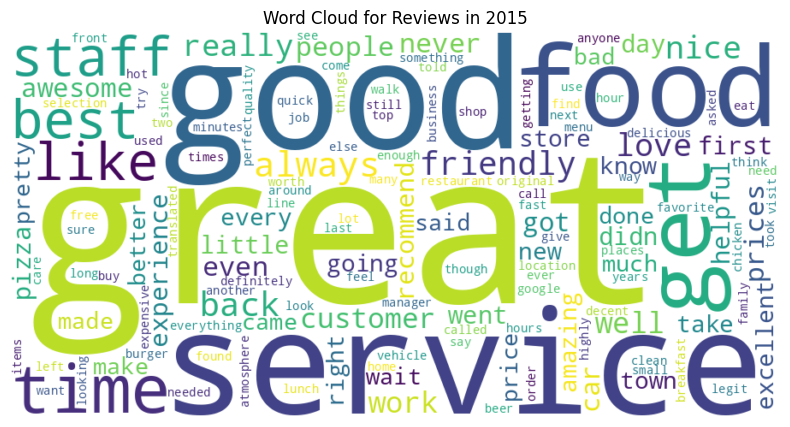

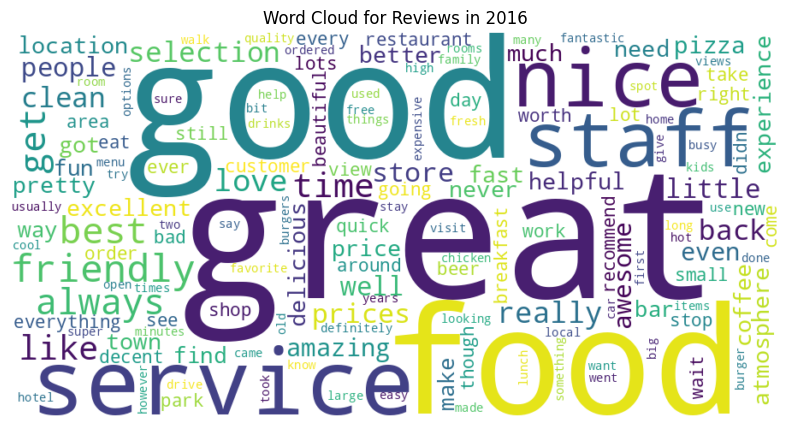

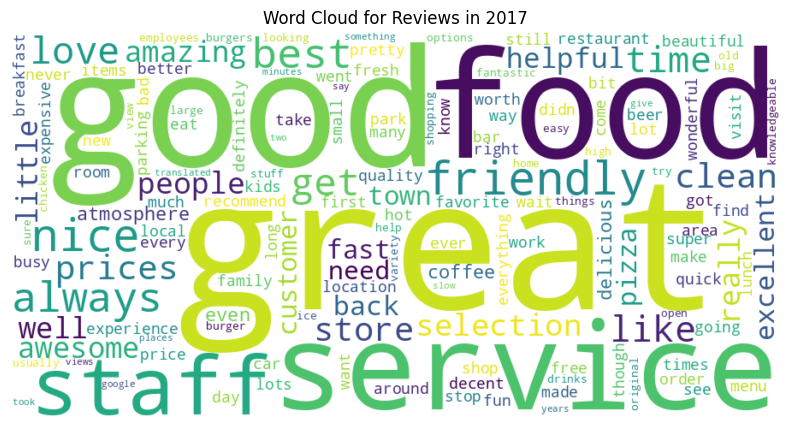

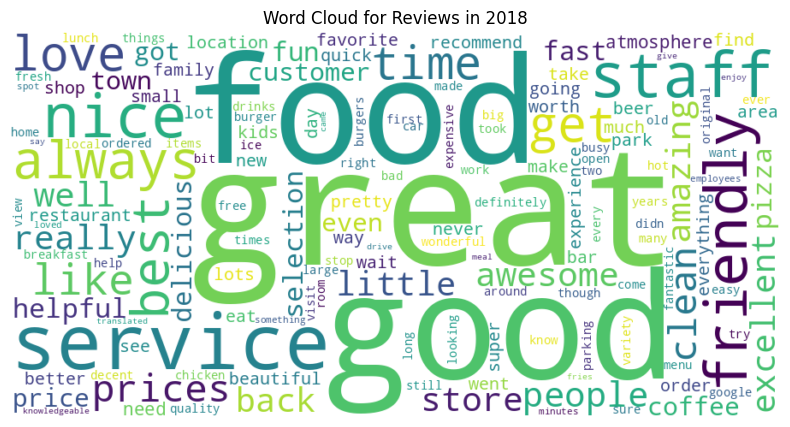

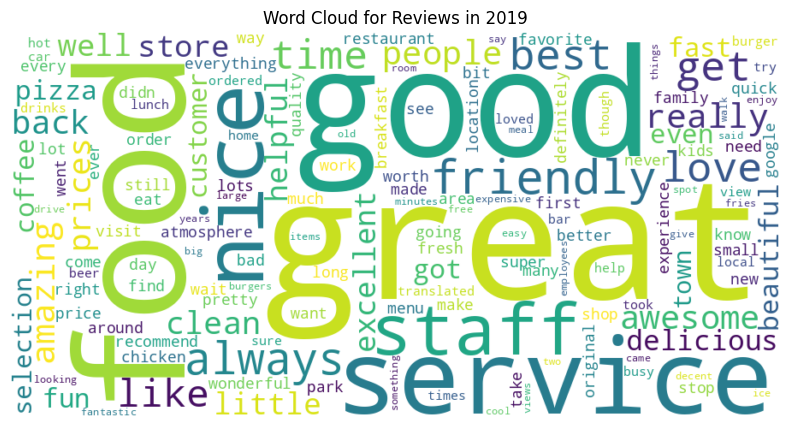

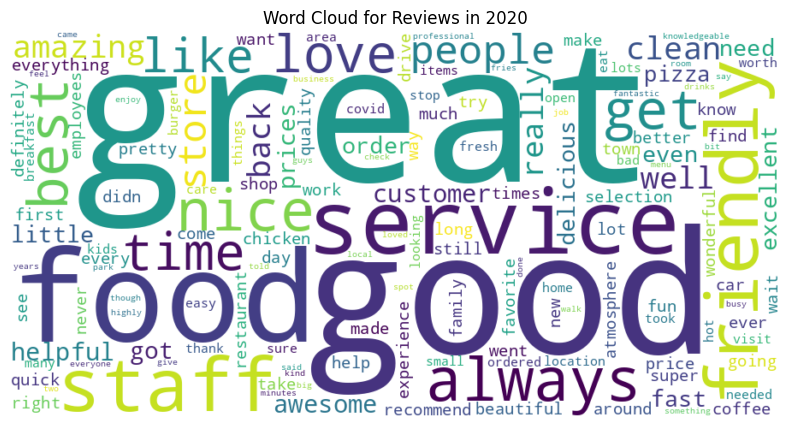

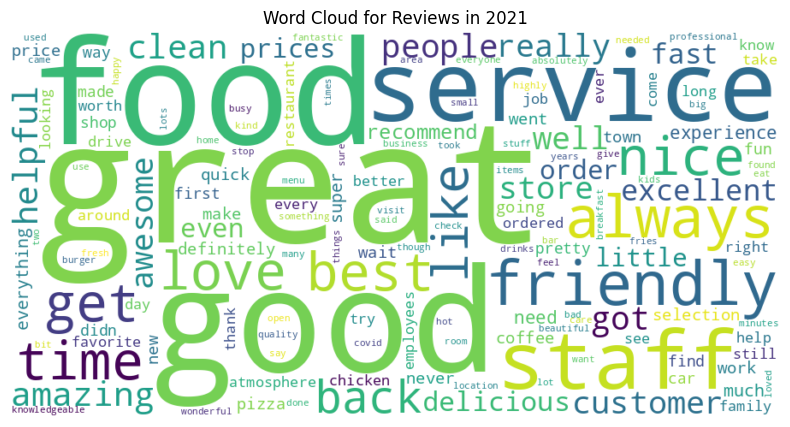

In [22]:
# ==========================================
# FAST word clouds for ALL years
# Spark counts tokens; WordCloud uses frequencies
# ==========================================
import pyspark.sql.functions as F
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover
from wordcloud import WordCloud
import matplotlib.pyplot as plt


df_wc = (
    df_review_clean
    .select("text", F.year(F.to_date("newtime")).alias("year"))
    .filter(F.col("text").isNotNull() & F.col("year").isNotNull())
)

# Tokenize in Spark (lowercased, split on non-letters)
regex_tok = RegexTokenizer(inputCol="text", outputCol="tokens", pattern="\\W+", toLowercase=True)
df_tok = regex_tok.transform(df_wc)

# Remove stopwords (extend with your own if desired)
remover = StopWordsRemover(inputCol="tokens", outputCol="clean_tokens")

# adding domain stopwords to speed up & improve quality
extra_stops = ["alaska","anchorage","review","reviews","place","one","would","also","im","ive","dont"]
remover.setStopWords(list(set(remover.getStopWords() + extra_stops)))
df_clean = remover.transform(df_tok)

# Explode tokens and keep tokens of length >=3 (fewer, cleaner; faster)
df_words = (
    df_clean
    .withColumn("token", F.explode("clean_tokens"))
    .filter(F.length("token") >= 3)
)

# Count in Spark: frequencies per (year, token)
df_counts = (
    df_words.groupBy("year", "token")
    .agg(F.count("*").alias("freq"))
    .cache()
)

# Pull only the aggregated counts to pandas (much smaller than raw text)
pdf_counts = df_counts.toPandas()

# Generate WordCloud per year from frequencies (very fast)
years = sorted(pdf_counts["year"].dropna().unique())
for y in years:
    freqs = (
        pdf_counts.loc[pdf_counts["year"] == y, ["token","freq"]]
        .set_index("token")["freq"]
        .to_dict()
    )
    if not freqs:
        continue

    wc = WordCloud(width=900, height=450, background_color="white",
                   max_words=150).generate_from_frequencies(freqs)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for Reviews in {int(y)}")
    plt.show()


Top 10 Businesses by Unique Reviewers:

               business_name  unique_reviewers
Moose's Tooth Pub & Pizzeria              2833
                      Subway              1637
                  McDonald's              1613
                       Carrs              1500
                   Starbucks              1351
                   Taco Bell               877
                       Petco               854
                  Fred Meyer               786
          Three Bears Alaska               733
           Beluga Point Site               709

Top 10 Categories by Unique Reviewers:

                                   business_category  unique_reviewers
                                     ['Coffee shop']              3000
['Pizza restaurant', 'Bar', 'Brewpub', 'Restaurant']              2833
                                      ['Restaurant']              2258
                                     ['Gas station']              1975
                              ['Mexican restaur

/tmp/ipython-input-1646866577.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reviews_by_weekday, x="weekday_name", y="user_id", palette="Set2")


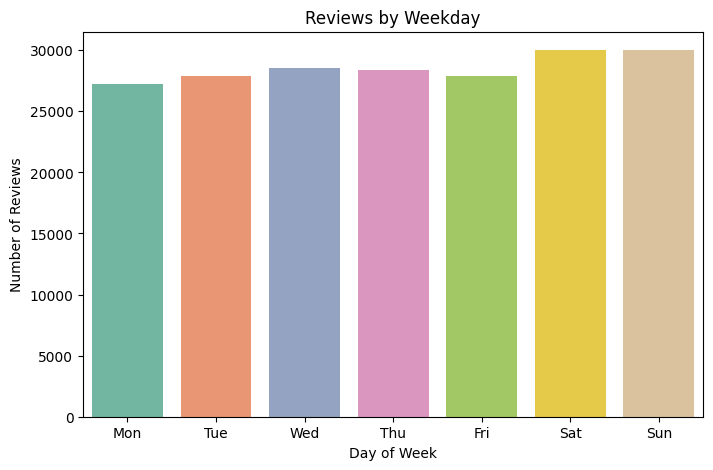

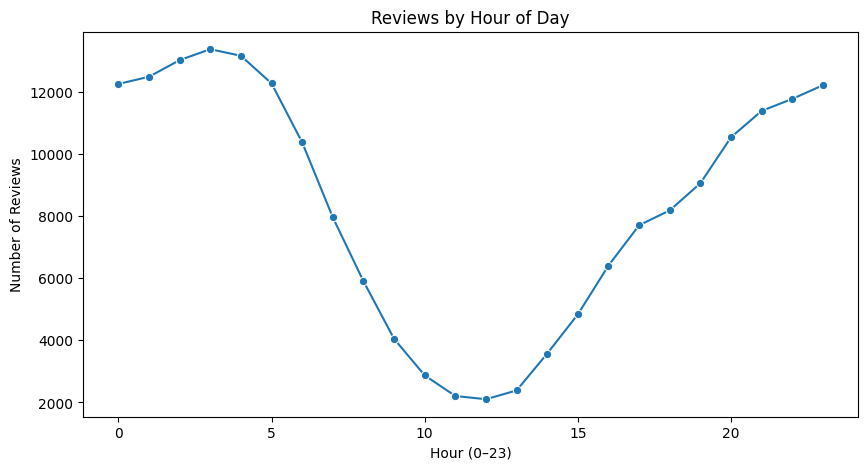

/tmp/ipython-input-1646866577.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reviews_by_year, x="year", y="user_id", palette="viridis")


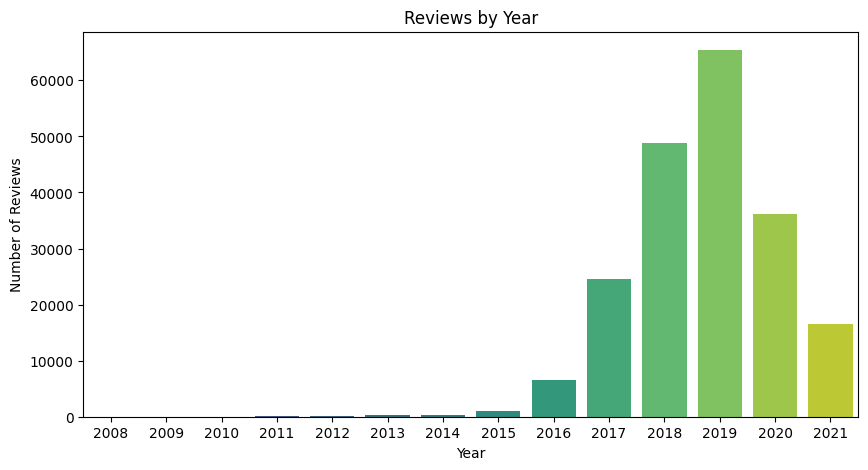

In [21]:
# ==============================================================
# PART 1 — Q1.5
# Reviewer analysis by business / category + temporal patterns
# ==============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------
# Prepare data
# ---------------------------------
# Convert Spark DF to Pandas with reviewer info
df_rev = df_joined.select(
    "gmap_id", "user_id", "time", "business_name", "business_category"
).limit(200000).toPandas()

# Convert epoch ms to datetime
df_rev["time"] = pd.to_numeric(df_rev["time"], errors="coerce")
df_rev["time_dt"] = pd.to_datetime(
    df_rev["time"].apply(lambda x: x/1000 if x and x > 1e12 else x),
    unit="s", errors="coerce"
)

# Extract useful temporal features
df_rev["year"] = df_rev["time_dt"].dt.year
df_rev["month"] = df_rev["time_dt"].dt.month
df_rev["weekday"] = df_rev["time_dt"].dt.dayofweek
df_rev["hour"] = df_rev["time_dt"].dt.hour

weekday_map = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}
df_rev["weekday_name"] = df_rev["weekday"].map(weekday_map)

# ---------------------------------
#  Unique reviewers per business
# ---------------------------------
unique_reviewers_business = (
    df_rev.groupby("business_name")["user_id"].nunique()
    .reset_index()
    .rename(columns={"user_id": "unique_reviewers"})
    .sort_values("unique_reviewers", ascending=False)
)

print("Top 10 Businesses by Unique Reviewers:\n")
print(unique_reviewers_business.head(10).to_string(index=False))

# ---------------------------------
# Unique reviewers per category
# ---------------------------------
unique_reviewers_category = (
    df_rev.groupby("business_category")["user_id"].nunique()
    .reset_index()
    .rename(columns={"user_id": "unique_reviewers"})
    .sort_values("unique_reviewers", ascending=False)
)

print("\nTop 10 Categories by Unique Reviewers:\n")
print(unique_reviewers_category.head(10).to_string(index=False))

# ---------------------------------
# Temporal patterns
# ---------------------------------

# Reviews by weekday
reviews_by_weekday = df_rev.groupby("weekday_name")["user_id"].count().reindex(
    ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=reviews_by_weekday, x="weekday_name", y="user_id", palette="Set2")
plt.title("Reviews by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Number of Reviews")
plt.show()

# Reviews by hour of day
reviews_by_hour = df_rev.groupby("hour")["user_id"].count().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=reviews_by_hour, x="hour", y="user_id", marker="o")
plt.title("Reviews by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Number of Reviews")
plt.show()

# Reviews by year
reviews_by_year = df_rev.groupby("year")["user_id"].count().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=reviews_by_year, x="year", y="user_id", palette="viridis")
plt.title("Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

**1.6 Recommendation Strategy**

1. **Data Preparation**

Use user_id, business_name, and rating to build a user business matrix.

Each row = user, each column = business, and values = rating.

Missing values are filled with 0 since not every user reviews every business.

2. **Collaborative Filtering**

Apply KNN (cosine similarity) on the user–business matrix.

The model identifies businesses that are most similar based on user rating patterns.

A business is recommended if it was highly rated by “similar” users.

3. **Hybrid Enhancement**

Use business_category as a fallback strategy:

If a user has no review history (cold start problem), recommend top-rated businesses within categories they have shown interest in.

Ensures recommendations are meaningful even for new users.

4. **Interpretability**

Recommendations are easy to explain to users:

Example: If a user loves “Coffee Shops” and rated “Starbucks Downtown” highly,
the model suggests other coffee shops such as “13 Ravens Coffee & Books” or “Espresso Expressions.”

In [26]:
# ==============================================================
# PART 1 — Q1.6  Business Recommendation System
# Strategy:
# - Item-based KNN with cosine similarity
# - User-based recommendations (item-neighbor scoring)
# - Category fallback for cold-start users
# ==============================================================

import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import pyspark.sql.functions as F

# -----------------------------
# Step 0: Prepare Data (ensure df_joined exists)
# -----------------------------
LIMIT_ROWS = 400_000  # limit for Colab performance
pdf = (df_joined
       .select(F.col("user_id").cast("string"),  # cast to string to avoid float IDs
               "business_name", "rating", "business_category")
       .limit(LIMIT_ROWS)
       .toPandas())

# Drop invalid ratings
pdf = pdf.dropna(subset=["user_id", "business_name", "rating"])
pdf["rating"] = pd.to_numeric(pdf["rating"], errors="coerce")
pdf = pdf[(pdf["rating"] > 0) & (pdf["rating"] <= 5)]

# -----------------------------
# Step 1: Filter to reduce sparsity
# -----------------------------
MIN_USER_RATINGS = 2
MIN_ITEM_RATINGS = 5

user_counts = pdf.groupby("user_id")["business_name"].nunique()
item_counts = pdf.groupby("business_name")["user_id"].nunique()

keep_users = set(user_counts[user_counts >= MIN_USER_RATINGS].index)
keep_items = set(item_counts[item_counts >= MIN_ITEM_RATINGS].index)

pdf_filt = pdf[pdf["user_id"].isin(keep_users) & pdf["business_name"].isin(keep_items)].copy()

# -----------------------------
# Step 2: Build User × Business Matrix
# -----------------------------
user_business = pdf_filt.pivot_table(
    index="user_id", columns="business_name", values="rating", aggfunc="mean"
).fillna(0)

# Item × User matrix for item-based KNN
item_user = user_business.T
item_user_sparse = csr_matrix(item_user.values)

# -----------------------------
# Step 3: Fit KNN (Item-based CF)
# -----------------------------
knn_items = NearestNeighbors(metric="cosine", algorithm="brute")
knn_items.fit(item_user_sparse)

print(f"[INFO] Matrix sizes — users: {user_business.shape[0]}, items: {user_business.shape[1]}")

# -----------------------------
# Step 4: Recommend similar businesses
# -----------------------------
def recommend_similar_businesses(business_name: str, n_recommendations: int = 5):
    if business_name not in item_user.index:
        return f" Business '{business_name}' not found in dataset."

    idx = item_user.index.get_loc(business_name)
    query_vec = item_user.iloc[idx, :].values.reshape(1, -1)

    distances, indices = knn_items.kneighbors(query_vec, n_neighbors=n_recommendations + 1)

    recs = []
    for r in range(1, len(indices.flatten())):  # skip self
        biz_idx = indices.flatten()[r]
        sim = 1 - distances.flatten()[r]
        recs.append((item_user.index[biz_idx], round(float(sim), 3)))
    return recs

# -----------------------------
# Step 5: User-based recommendations
# -----------------------------
_item_neighbors_cache = {}
def get_item_neighbors(business_name: str, k: int = 25):
    if business_name not in item_user.index:
        return []
    if (business_name, k) in _item_neighbors_cache:
        return _item_neighbors_cache[(business_name, k)]

    idx = item_user.index.get_loc(business_name)
    query_vec = item_user.iloc[idx, :].values.reshape(1, -1)
    distances, indices = knn_items.kneighbors(query_vec, n_neighbors=k + 1)

    neigh = []
    for r in range(1, len(indices.flatten())):
        biz_idx = indices.flatten()[r]
        sim = 1 - distances.flatten()[r]
        neigh.append((item_user.index[biz_idx], float(sim)))
    _item_neighbors_cache[(business_name, k)] = neigh
    return neigh

def recommend_for_user(user_id: str, top_n: int = 10, k_neighbors: int = 25,
                       min_sim: float = 0.05, mean_center: bool = True):
    if user_id not in user_business.index:
        return f" user_id '{user_id}' not found."

    user_ratings = user_business.loc[user_id].copy()
    rated_items = set(user_ratings[user_ratings > 0].index)
    if not rated_items:
        return " Cold-start user: no ratings found."

    if mean_center:
        mu = user_ratings[list(rated_items)].mean()  # FIX: list() not set
    else:
        mu = 0.0

    scores, sim_sums = {}, {}
    for item in rated_items:
        neighbors = get_item_neighbors(item, k=k_neighbors)
        for neigh_item, sim in neighbors:
            if sim < min_sim or neigh_item in rated_items:
                continue
            contrib = (user_ratings[item] - mu) * sim
            scores[neigh_item]   = scores.get(neigh_item, 0.0) + contrib
            sim_sums[neigh_item] = sim_sums.get(neigh_item, 0.0) + sim

    recs = [(it, sc / sim_sums.get(it, 1e-9)) for it, sc in scores.items()]
    recs = sorted(recs, key=lambda x: x[1], reverse=True)[:top_n]
    return [(biz, round(float(score), 3)) for biz, score in recs]

# -----------------------------
# Step 6: Category fallback
# -----------------------------
def _norm_cat_str(val):
    if isinstance(val, str):
        return val
    try:
        return ", ".join(val)
    except Exception:
        return str(val)

def top_in_category(category_query: str, top_n: int = 10, min_reviews: int = 3):
    tmp = pdf[["business_name", "business_category", "rating"]].copy()
    tmp["business_category"] = tmp["business_category"].apply(_norm_cat_str)

    sub = tmp[tmp["business_category"].str.contains(category_query, case=False, na=False)]
    agg = (sub.groupby("business_name")
           .agg(avg_rating=("rating", "mean"), n_reviews=("rating", "count"))
           .query("n_reviews >= @min_reviews")
           .sort_values(["avg_rating", "n_reviews"], ascending=[False, False])
           .head(top_n)
           .reset_index())
    return [(r["business_name"], round(float(r["avg_rating"]), 2), int(r["n_reviews"]))
            for _, r in agg.iterrows()]

# ==============================================================
# EXAMPLES
# ==============================================================
from math import isfinite

# ---------------------------
# A) Similar businesses table
# ---------------------------
seed_business = popular_business  # e.g., "McDonald's"
recs_sim = recommend_similar_businesses(seed_business, n_recommendations=5)

df_sim = pd.DataFrame(recs_sim, columns=["Business", "Similarity"])
df_sim["Similarity"] = df_sim["Similarity"].apply(lambda x: f"{x:.3f}" if isfinite(x) else "")
df_sim.insert(0, "Rank", range(1, len(df_sim) + 1))

print(f"\nSimilar businesses to '{seed_business}':")
print(df_sim.to_string(index=False))

# -------------------------------------------
# B) User recommendations (pretty + safe id)
# -------------------------------------------
# Ensure the example_user is exactly what you passed to recommend_for_user
user_id_str = str(example_user)  # avoid scientific notation in prints
recs_user = recommend_for_user(example_user, top_n=5, k_neighbors=25)

df_user = pd.DataFrame(recs_user, columns=["Business", "Score"])
df_user["Score"] = df_user["Score"].apply(lambda x: f"{x:.3f}" if isfinite(x) else "")
df_user.insert(0, "Rank", range(1, len(df_user) + 1))

print(f"\nRecommendations for user_id={user_id_str}:")
print(df_user.to_string(index=False))

# -------------------------------------------
# C) Category fallback table (e.g., "Coffee")
# -------------------------------------------
cat_query = "Coffee"
top_cat = top_in_category(cat_query, top_n=5)

df_cat = pd.DataFrame(top_cat, columns=["Business", "Avg. Rating", "# Reviews"])
df_cat["Avg. Rating"] = df_cat["Avg. Rating"].apply(lambda x: f"{x:.2f}" if isfinite(x) else "")
df_cat.insert(0, "Rank", range(1, len(df_cat) + 1))

print(f"\nTop {cat_query} category businesses (fallback):")
print(df_cat.to_string(index=False))


[INFO] Matrix sizes — users: 20017, items: 4823

Similar businesses to 'McDonald's':
 Rank            Business Similarity
    1 Walmart Supercenter      0.415
    2           Taco Bell      0.394
    3              Subway      0.334
    4             Safeway      0.323
    5          Fred Meyer      0.305

Recommendations for user_id=1.0000266958784963E20:
 Rank                     Business Score
    1  Mom & Pops Liquor & Grocery 1.125
    2  6th Avenue Outfitters Co-op 1.125
    3            SteamDot Williwaw 1.125
    4 Cook Inlet Housing Authority 1.125
    5           Michael's Jewelers 1.125

Top Coffee category businesses (fallback):
 Rank                         Business Avg. Rating  # Reviews
    1 Mermaid Grotto Cafe and Boutique        5.00         15
    2    The Green Coffee Bean Company        5.00         12
    3         13 Ravens Coffee & Books        5.00         11
    4                    Soda & S'more        4.95         21
    5         Goldie's Coffee Roasters   

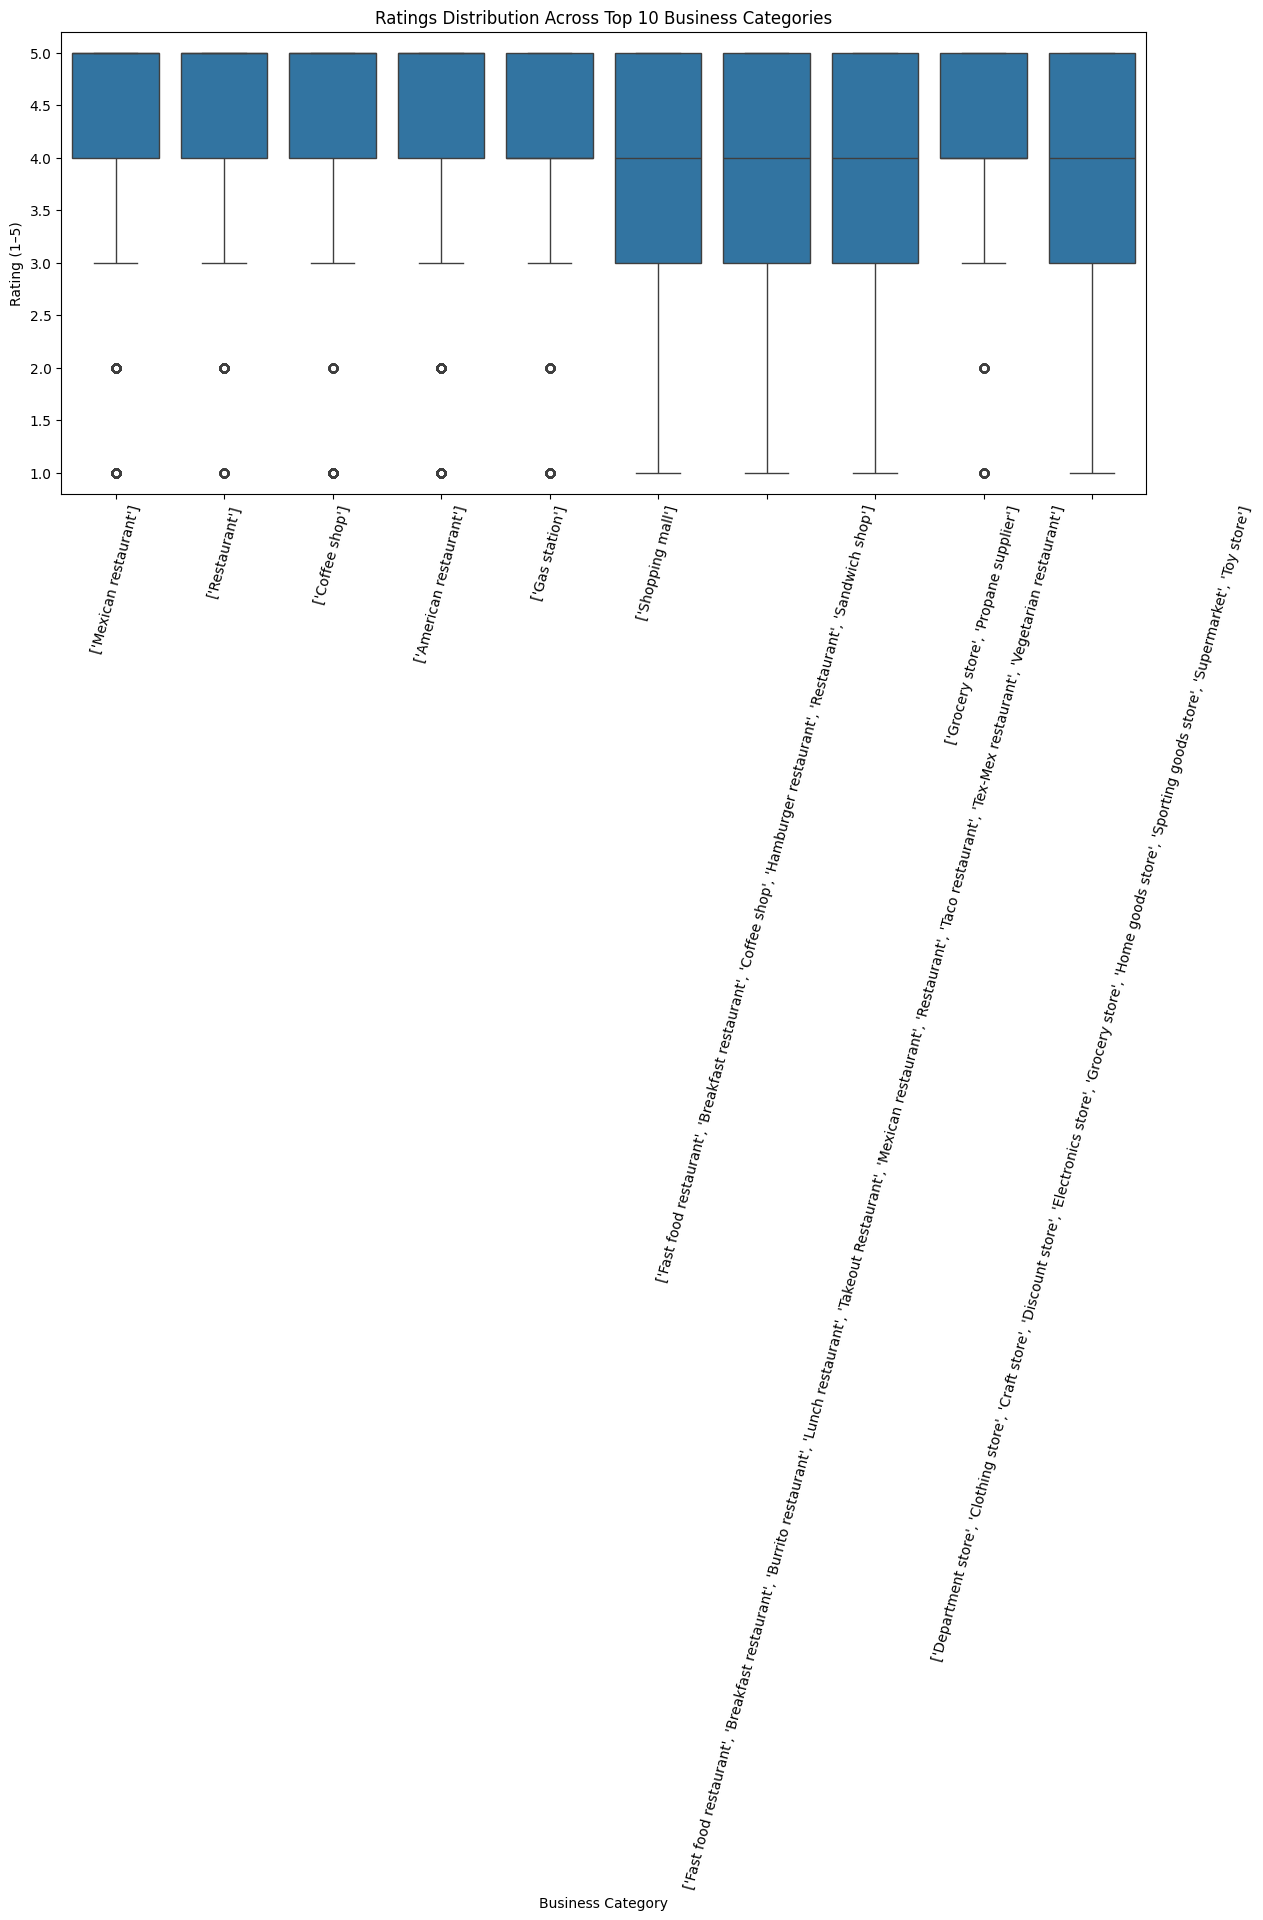

/tmp/ipython-input-3134083181.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_avg.values, y=cat_avg.index, palette="viridis")


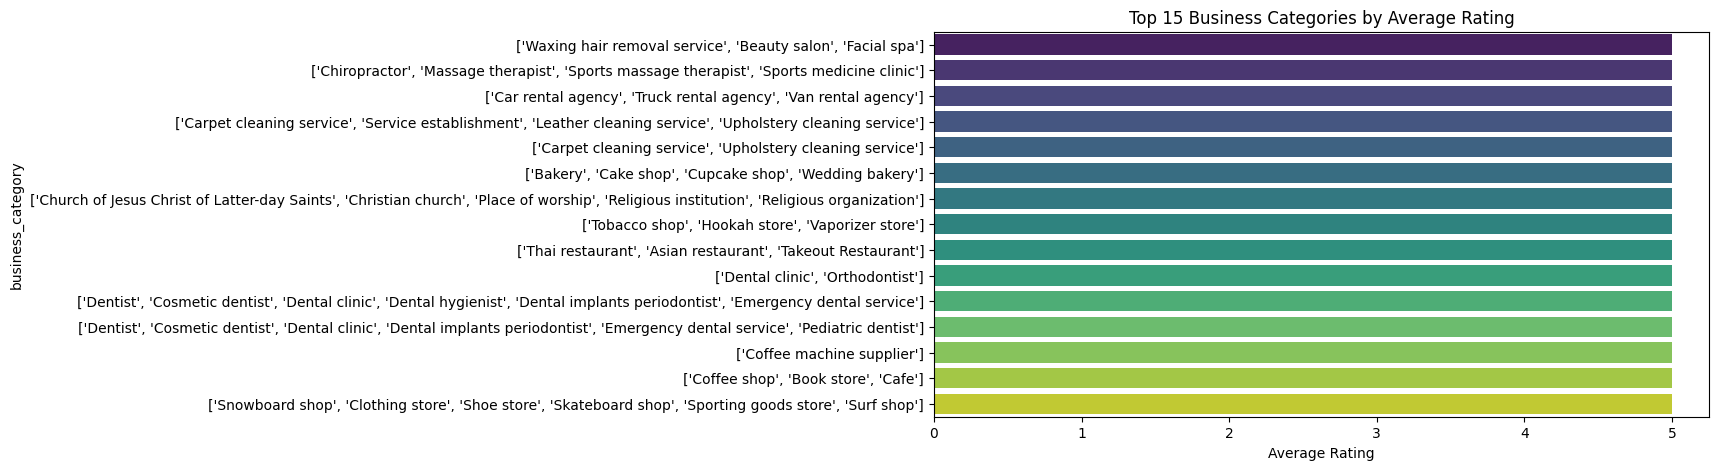

In [27]:
# ==============================================================
# PART 1 — Q1.7  Exploring Rating
# ==============================================================

# Prepare data
df_plot = pdf.copy()
df_plot["business_category"] = df_plot["business_category"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) else str(x)
)
# ---------------------------------
# 1.7.1 Build Visualizations
# ---------------------------------
# --- Visualization 1: Boxplot of Ratings by Category ---
plt.figure(figsize=(14,6))
top_cats = df_plot["business_category"].value_counts().head(10).index
sns.boxplot(data=df_plot[df_plot["business_category"].isin(top_cats)],
            x="business_category", y="rating")
plt.xticks(rotation=75)
plt.title("Ratings Distribution Across Top 10 Business Categories")
plt.ylabel("Rating (1–5)")
plt.xlabel("Business Category")
plt.show()

# --- Visualization 2: Average Rating by Category ---
cat_avg = (df_plot.groupby("business_category")["rating"]
           .mean().sort_values(ascending=False).head(15))

plt.figure(figsize=(10,5))
sns.barplot(x=cat_avg.values, y=cat_avg.index, palette="viridis")
plt.title("Top 15 Business Categories by Average Rating")
plt.xlabel("Average Rating")
plt.show()


Top 30 most frequent words in low-rating reviews:
           Word  Frequency
0             e      28642
1    restaurant       1510
2        alaska       1384
3     anchorage       1254
4     mcdonalds       1141
5           the        907
6         pizza        903
7         grill        844
8        center        767
9       walmart        751
10  supercenter        709
11         park        676
12          and        617
13         mall        616
14          bar        594
15         taco        590
16           of        582
17        store        573
18         auto        503
19         bell        487
20          inn        469
21         king        430
22        house        393
23         cafe        384
24      mexican        384
25        hotel        349
26      wasilla        342
27    starbucks        331
28       burger        331
29        parts        321


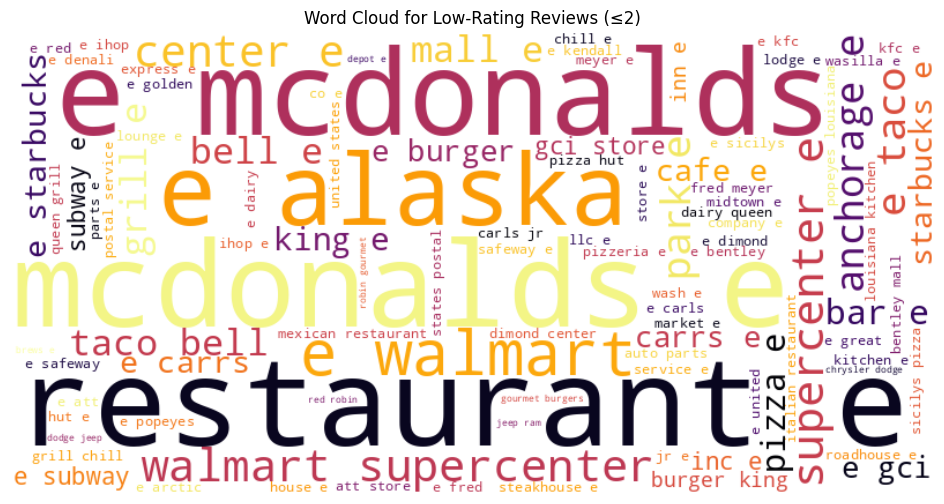

In [28]:
# ---------------------------------
# 1.7.2 Reviews on Lower Ratings
# ---------------------------------

# Filter reviews with rating <= 2
low_reviews = pdf[pdf["rating"] <= 2].copy()

# Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)       # remove links
    text = re.sub(r"[^a-z\s]", "", text)      # keep letters only
    return text.strip()

low_reviews["clean_text"] = low_reviews["business_name"].astype(str) + " " + low_reviews["rating"].astype(str) + " " + low_reviews["user_id"].astype(str)
low_reviews["clean_text"] = low_reviews["clean_text"].apply(clean_text)

# Word frequency analysis
tokens = " ".join(low_reviews["clean_text"]).split()
common_words = Counter(tokens).most_common(30)

print("Top 30 most frequent words in low-rating reviews:")
print(pd.DataFrame(common_words, columns=["Word", "Frequency"]))

# --- Wordcloud for low rating reviews ---
text_str = " ".join(tokens)
wc = WordCloud(width=800, height=400, background_color="white",
               colormap="inferno", max_words=100).generate(text_str)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Low-Rating Reviews (≤2)")
plt.show()


In [29]:
# ==============================================================
# Q1.8 — Reviewer-Level Exploration
#  - 1.8.1 Build time-ordered business list per user
# ==============================================================

from itertools import combinations

if "newtime" not in df_joined.columns:
    # Handle BIGINT milliseconds and seconds robustly
    time_as_long = F.col("time").cast("long")
    epoch_secs = F.when(time_as_long >= F.lit(10**12), (time_as_long / 1000).cast("long")).otherwise(time_as_long)
    df_joined = df_joined.withColumn("newtime", F.date_format(F.from_unixtime(epoch_secs), "yyyy-MM-dd"))

# --------------------------------------------------------------
# 1.8.1  Build user -> time-ordered list of businesses
#   We will:
#     (a) cast newtime to date for proper ordering,
#     (b) pack (newtime, business_name) into structs,
#     (c) collect_list, then sort the array by date,
#     (d) transform to just business_name in temporal order
# --------------------------------------------------------------
df_hist = (
    df_joined
    .select(
        F.col("user_id").cast("string").alias("user_id"),  # cast to string to avoid scientific notation issues
        F.col("business_name"),
        F.to_date(F.col("newtime")).alias("newtime_dt")
    )
    .filter(F.col("business_name").isNotNull() & F.col("newtime_dt").isNotNull())
)

# Pack (date, name) into structs -> collect -> sort -> extract names
df_hist_packed = (
    df_hist
    .select("user_id", F.struct(F.col("newtime_dt").alias("d"), F.col("business_name").alias("n")).alias("s"))
)

df_user_lists = (
    df_hist_packed
    .groupBy("user_id")
    .agg(
        F.sort_array(F.collect_list("s")).alias("arr")  # sort by date (structs sort lexicographically: d then n)
    )
    .select(
        "user_id",
        F.expr("transform(arr, x -> x.n)").alias("business_list")  # keep only business names in temporal order
    )
)

# Convert to a compact Python dict: user_id -> [business1, business2, ...]
pdf_user_lists = df_user_lists.toPandas()
user_business_list = dict(zip(pdf_user_lists["user_id"], pdf_user_lists["business_list"]))

# Preview one user
some_user = next(iter(user_business_list.keys()))
print(f"Example (first 10) for user {some_user}: {user_business_list[some_user][:10]}")
print(f"Total users with history: {len(user_business_list)}")

Example (first 10) for user 1.0000266958784963E20: ["McDonald's" 'New Sagaya Midtown Market'
 'Extended Stay America - Anchorage - Midtown' 'Lucky Market'
 'Midtown Mall' 'Walmart Supercenter' "McDonald's"
 "Moose's Tooth Pub & Pizzeria" 'Table 6' '2GO Tesoro']
Total users with history: 20022


In [30]:
# --------------------------------------------------------------
# 1.8.2  Remove duplicates per user (preserve first occurrence order)
#        Print element counts before and after for each user
#        Also print a small sample and global summary deltas
# --------------------------------------------------------------
def dedup_preserve_order(seq):
    seen = set()
    out = []
    for x in seq:
        if x not in seen:
            out.append(x)
            seen.add(x)
    return out

# Counts before
before_counts = {u: len(lst) for u, lst in user_business_list.items()}

# De-duplicate
user_business_list_nodup = {u: dedup_preserve_order(lst) for u, lst in user_business_list.items()}

# Counts after
after_counts = {u: len(lst) for u, lst in user_business_list_nodup.items()}

# Print sample (first 5 users)
print("\nUser  |  #Before  ->  #After")
for u in list(user_business_list.keys())[:5]:
    print(f"{u}  |  {before_counts[u]:>7}  ->  {after_counts[u]:>5}")

# Summary deltas
total_before = sum(before_counts.values())
total_after  = sum(after_counts.values())
print(f"\nGlobal counts — total elements before: {total_before:,} | after: {total_after:,} | removed: {total_before - total_after:,}")


User  |  #Before  ->  #After
1.0000266958784963E20  |       23  ->     21
1.0000609083371541E20  |       48  ->     46
1.0000620838495144E20  |       21  ->     20
1.0000684986283477E20  |       10  ->     10
1.000069682173995E20  |       19  ->     19

Global counts — total elements before: 521,997 | after: 492,494 | removed: 29,503


In [33]:
# --------------------------------------------------------------
# 1.8.3  User similarity by past reviewed business
#   Strategy A: Jaccard similarity on sets (easy to explain)
#   Strategy B: Cosine similarity on binary user×business matrix (scalable)
# --------------------------------------------------------------

from scipy.sparse import csr_matrix
# --------------------------------------------------------------
# STRATEGY A — Jaccard Similarity
#   J(u, v) = |Bu ∩ Bv| / |Bu ∪ Bv|
# --------------------------------------------------------------
def jaccard_similarity(set1, set2):
    if not set1 or not set2:
        return 0.0
    return len(set1 & set2) / len(set1 | set2)

# Build sets for each user
user_sets = {u: set(lst) for u, lst in user_business_list.items()}

# Compute pairwise Jaccard on a sample (to avoid O(N^2) explosion)
sample_users = list(user_sets.keys())[:300]   # limit sample size for speed
pairs = []
for i, u1 in enumerate(sample_users):
    for u2 in sample_users[i+1:]:
        sim = jaccard_similarity(user_sets[u1], user_sets[u2])
        if sim > 0:
            pairs.append((u1, u2, round(sim, 3)))

df_jaccard = pd.DataFrame(pairs, columns=["User1", "User2", "Jaccard_Similarity"])
print("Top 10 user pairs by Jaccard similarity:")
print(df_jaccard.sort_values("Jaccard_Similarity", ascending=False).head(10))

# --------------------------------------------------------------
# STRATEGY B — Cosine Similarity on User×Business Matrix
#   - Build sparse matrix (users × businesses)
#   - Use NearestNeighbors with cosine distance
# --------------------------------------------------------------
# Build index maps
users = list(user_business_list.keys())
items = sorted({b for lst in user_business_list.values() for b in lst})
user_to_idx = {u: i for i, u in enumerate(users)}
item_to_idx = {b: i for i, b in enumerate(items)}

# Build sparse matrix (1 if user reviewed business)
rows, cols, data = [], [], []
for u, businesses in user_business_list.items():
    for b in businesses:
        rows.append(user_to_idx[u])
        cols.append(item_to_idx[b])
        data.append(1)

X = csr_matrix((data, (rows, cols)), shape=(len(users), len(items)))

# Fit KNN on user vectors
knn = NearestNeighbors(metric="cosine", algorithm="brute")
knn.fit(X)

# Function to get nearest neighbors for a user
def top_similar_users(user_id, k=5):
    if user_id not in user_to_idx:
        return []
    idx = user_to_idx[user_id]
    distances, indices = knn.kneighbors(X[idx], n_neighbors=k+1)
    results = []
    for r in range(1, len(indices.flatten())):  # skip self
        neighbor = users[indices.flatten()[r]]
        sim = 1 - distances.flatten()[r]
        results.append((neighbor, round(float(sim), 3)))
    return results

# Example: cosine neighbors for the first user
example_user = users[0]
print(f"\nCosine-based nearest neighbors for user {example_user}:")
print(top_similar_users(example_user, k=5))




Top 10 user pairs by Jaccard similarity:
                       User1                  User2  Jaccard_Similarity
19441  1.0041648727849982E20   1.004250172563465E20               0.286
1465   1.0001363442299698E20  1.0022552595204933E20               0.235
17017  1.0029727017288268E20  1.0047263201996795E20               0.211
15528  1.0027263136006172E20  1.0031834238398423E20               0.211
9929    1.001405514825304E20  1.0029585091241248E20               0.211
15876  1.0027671383236182E20   1.003223060614842E20               0.208
785     1.000069682173995E20   1.003237037520255E20               0.208
17896  1.0032592629076525E20   1.004786841123609E20               0.205
16961  1.0029685363745341E20    1.00488792998905E20               0.200
19180  1.0039721652671719E20  1.0049222576644925E20               0.192

Cosine-based nearest neighbors for user 1.0000266958784963E20:
[('1.0385970098686842E20', 0.462), ('1.0327925775019372E20', 0.46), ('1.028112776559025E20', 0.459), ('

Sample of time series after filling missing dates:
            review_count
date                    
2007-10-13      1.000000
2007-10-14    163.635423
2007-10-15    163.635423
2007-10-16    163.635423
2007-10-17    163.635423


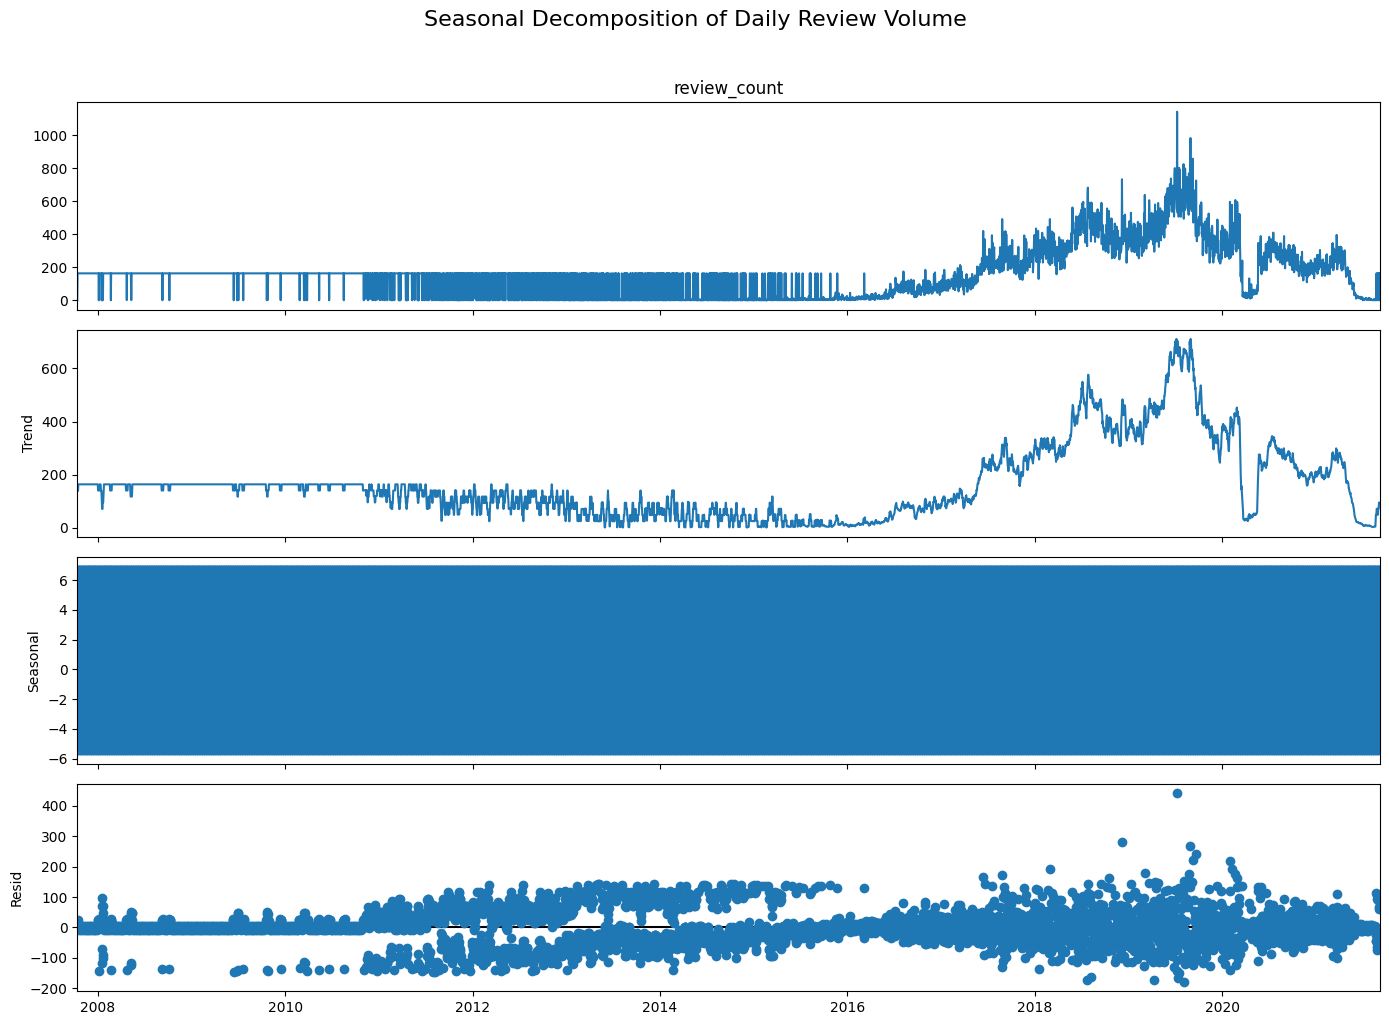

In [36]:
# ==============================================================
# Q2.1 — Time Series of Daily Review Volume
#   - Aggregate reviews per day
#   - Fill missing days with mean review count
#   - Decompose (additive) to analyze trend/seasonality
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# --------------------------------------------------------------
# STEP 1 — Prepare daily review counts
# --------------------------------------------------------------
df_time = df_joined.select("newtime").toPandas()
df_time["newtime"] = pd.to_datetime(df_time["newtime"], errors="coerce")
df_time = df_time.dropna(subset=["newtime"])

# Count reviews per day
daily_counts = df_time.groupby("newtime").size().rename("review_count")

# --------------------------------------------------------------
# STEP 2 — Fill missing days with mean review count
# --------------------------------------------------------------
# Full date range
full_range = pd.date_range(start=daily_counts.index.min(),
                           end=daily_counts.index.max(),
                           freq="D")

# Reindex to full range
ts_full = daily_counts.reindex(full_range)

# Fill missing with mean
mean_reviews = daily_counts.mean()
ts_full = ts_full.fillna(mean_reviews)

# Convert to DataFrame
ts_df = ts_full.to_frame(name="review_count")
ts_df.index.name = "date"

print("Sample of time series after filling missing dates:")
print(ts_df.head())

# --------------------------------------------------------------
# STEP 3 — Seasonal Decomposition (Additive)
# --------------------------------------------------------------
result = seasonal_decompose(ts_df["review_count"], model="additive", period=7)
# period=7 assumes weekly cycle; can adjust if data spans years

# Plot with better layout
fig = result.plot()
fig.set_size_inches(14, 10)  # Bigger figure for clarity

# Add a super title and fix overlaps
plt.suptitle("Seasonal Decomposition of Daily Review Volume", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


Best ARIMA params: (2, 0, 2), MAE=127.76

Top 5 ARIMA parameter sets by MAE:
ARIMA(2, 0, 2) → MAE=127.76
ARIMA(1, 0, 1) → MAE=127.97
ARIMA(2, 0, 1) → MAE=128.29
ARIMA(1, 0, 2) → MAE=131.84
ARIMA(2, 1, 0) → MAE=148.04


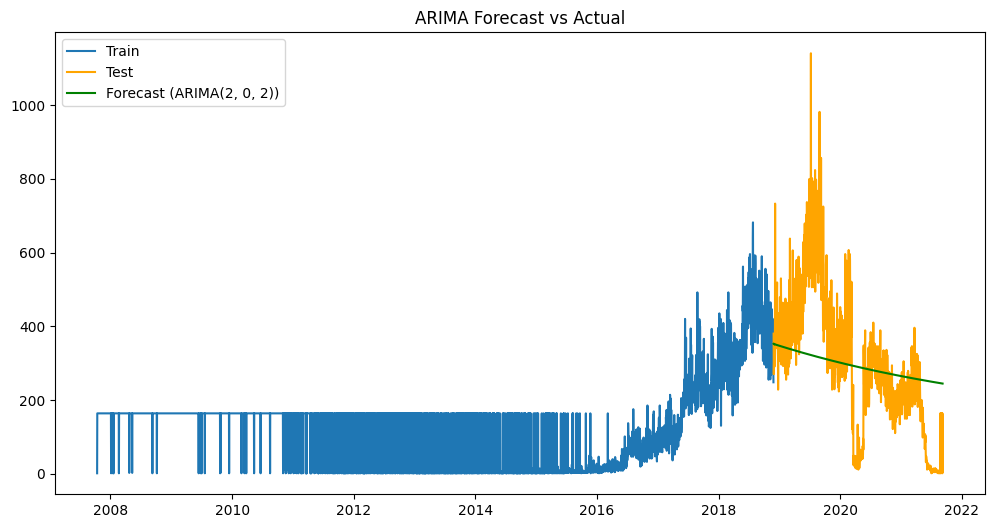

In [37]:
# ==============================================================
# Q2.2 — ARIMA Forecasting (Grid Search on p,d,q)
# ==============================================================

import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

# Use the daily review count series (from Q2.1)
y = ts_df["review_count"]

# --------------------------------------------------------------
# STEP 1 — Train/Test Split
# --------------------------------------------------------------
train_size = int(len(y) * 0.8)   # 80% train, 20% test
train, test = y.iloc[:train_size], y.iloc[train_size:]

# --------------------------------------------------------------
# STEP 2 — Grid Search over (p,d,q) ∈ [0,1,2]
# --------------------------------------------------------------
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_mae = np.inf
best_params = None
results = []

warnings.filterwarnings("ignore")

for params in pdq:
    try:
        model = ARIMA(train, order=params)
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=len(test))
        mae = mean_absolute_error(test, forecast)
        results.append((params, mae))
        if mae < best_mae:
            best_mae, best_params = mae, params
    except:
        continue

# --------------------------------------------------------------
# STEP 3 — Report best model
# --------------------------------------------------------------
print(f"Best ARIMA params: {best_params}, MAE={best_mae:.2f}")

# Top 5 results
results_sorted = sorted(results, key=lambda x: x[1])
print("\nTop 5 ARIMA parameter sets by MAE:")
for params, mae in results_sorted[:5]:
    print(f"ARIMA{params} → MAE={mae:.2f}")

# --------------------------------------------------------------
# STEP 4 — Fit best model & forecast future
# --------------------------------------------------------------
best_model = ARIMA(train, order=best_params).fit()
forecast = best_model.forecast(steps=len(test))

# Plot actual vs forecast
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="orange")
plt.plot(test.index, forecast, label=f"Forecast (ARIMA{best_params})", color="green")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()
